## Set up

In [15]:
import json
import pandas as pd
from collections import Counter

import matplotlib.pyplot as plt

In [16]:
LEMMAS_WITH_MEANINGS_AND_SENTENCES_PATH = './lemmas_with_meanings_and_sentences.json'

In [17]:
with open(LEMMAS_WITH_MEANINGS_AND_SENTENCES_PATH, 'r') as f:
    lemmas_with_meanings_and_sentences = json.load(f)

lemmas = list(lemmas_with_meanings_and_sentences.keys())
len(lemmas)

1464

## Print all lemmas, their meanings and all sentences for each meaning

In [18]:
sentences_distribution = []

for lemma, meanings_and_sentences in lemmas_with_meanings_and_sentences.items():
    # print(f'Lemma: {lemma}')

    for meaning_v in meanings_and_sentences.values():
        meaning = meaning_v['meaning']
        sentences = meaning_v['sentences']
        sentences_distribution.append(len(meaning_v['sentences']))
        
        # print(f'  Meaning: {meaning["gloss"][0]}')
        
        # if not sentences:
        #     print('    No example sentences available.')
        # else:
        #     for sentence in sentences:
        #         print(f'    (sim={sentence["similarity"]:.4f}, prob={sentence["probability"]:.4f}): {sentence["sentence"]}')
                
#     print()

count     1378.000000
mean       103.267779
std        581.760072
min          1.000000
25%          2.000000
50%          6.000000
75%         35.000000
90%        158.300000
95%        384.450000
99%       1762.070000
max      16832.000000
dtype: float64


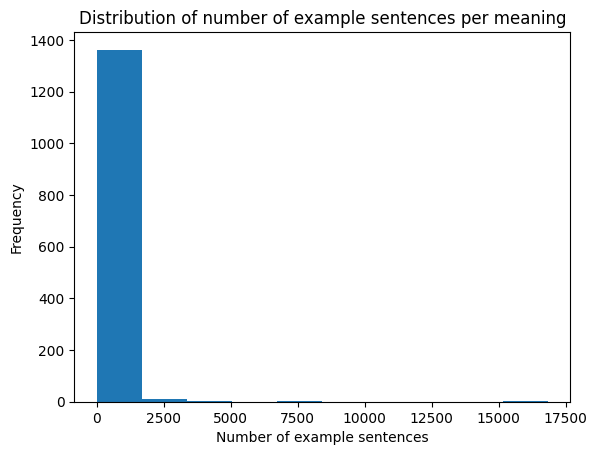

In [19]:
sentences_distribution = [i for i in sentences_distribution if i > 0]
print(pd.Series(sentences_distribution).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
plt.hist(sentences_distribution)
plt.title('Distribution of number of example sentences per meaning')
plt.xlabel('Number of example sentences')
plt.ylabel('Frequency')
plt.show()

In [20]:
# total meanings count
all_meanings_and_sentences = list(lemmas_with_meanings_and_sentences.values())
total_meanings_count = sum(len(meanings_and_sentences) for meanings_and_sentences in all_meanings_and_sentences)

print(f'Total meanings count: {total_meanings_count}')

Total meanings count: 3071


In [21]:
# total sentences count
sentences_per_meaning = [meaning_v['sentences'] for meanings_and_sentences in all_meanings_and_sentences for meaning_v in meanings_and_sentences.values()]
sentences_count_per_meaning = [len(sentences) for sentences in sentences_per_meaning]
total_sentences_count = sum(sentences_count_per_meaning)

print(f'Total sentences count: {total_sentences_count}')

Total sentences count: 142303


Sentences per meaning stats (excl. zeros):
count     1378.000000
mean       103.267779
std        581.760072
min          1.000000
25%          2.000000
50%          6.000000
75%         35.000000
90%        158.300000
95%        384.450000
99%       1762.070000
max      16832.000000
dtype: float64


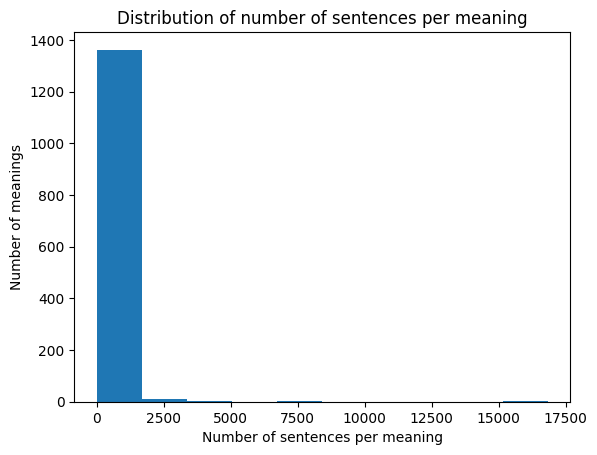

In [22]:
# number of sentences distribution per meaning
sentences_count_distribution = sentences_count_per_meaning[:]
# drop 0
sentences_count_distribution = [count for count in sentences_count_distribution if count > 0]

print(f'Sentences per meaning stats (excl. zeros):')
print(pd.Series(sentences_count_distribution).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))
# sentences_count_distribution = [min(count, 100) for count in sentences_count_distribution]

plt.hist(sentences_count_distribution)
plt.title('Distribution of number of sentences per meaning')
plt.xlabel('Number of sentences per meaning')
plt.ylabel('Number of meanings')
plt.show()

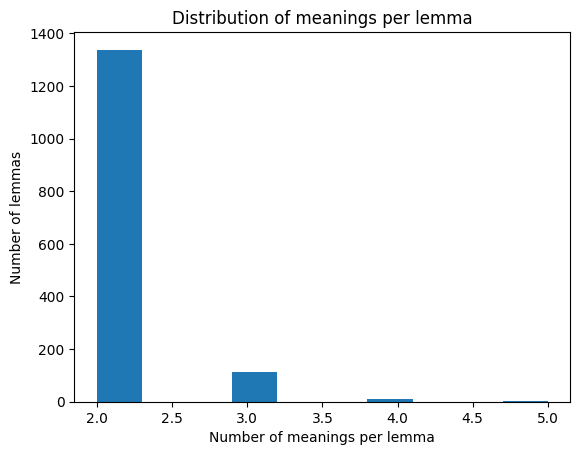

In [23]:
# distribution meanings per lemma
meanings_number = [len(i) for i in lemmas_with_meanings_and_sentences.values()]
plt.hist(meanings_number)
plt.title('Distribution of meanings per lemma')
plt.xlabel('Number of meanings per lemma')
plt.ylabel('Number of lemmas')
plt.show()

In [24]:
# total meanings without sentences
meanings_without_sentences_count = sum(
    1 for sentences_per_meaning in sentences_per_meaning if not sentences_per_meaning
)

print(f'Total meanings without sentences: {meanings_without_sentences_count}')

Total meanings without sentences: 1693


In [25]:
# total lemmas without meanings with sentences
not_presented_lemmas = sum(
    1 for meanings_and_sentences in lemmas_with_meanings_and_sentences.values() 
    if all(not meaning_v['sentences'] for meaning_v in meanings_and_sentences.values())
)

print(f'Total lemmas without meanings with sentences (lemmas that are not presented in dataset): {not_presented_lemmas} out of {len(lemmas)} ({len(lemmas) - not_presented_lemmas} presented)')

Total lemmas without meanings with sentences (lemmas that are not presented in dataset): 541 out of 1464 (923 presented)


In [26]:
before_after = {}

for lemma, meanings_and_sentences in list(lemmas_with_meanings_and_sentences.items()):
    sentences_count = []
    before_after[lemma] = {
        "before": len(meanings_and_sentences),
    }

    for meaning_key, meaning_v in meanings_and_sentences.items():
        sentences_count.append(len(meaning_v['sentences']))
    
    sentences_count = [i for i in sentences_count if i >= 1]
    if len(sentences_count) >= 2:
        before_after[lemma]["after"] = len(sentences_count)
    else:
        before_after[lemma]["after"] = 0

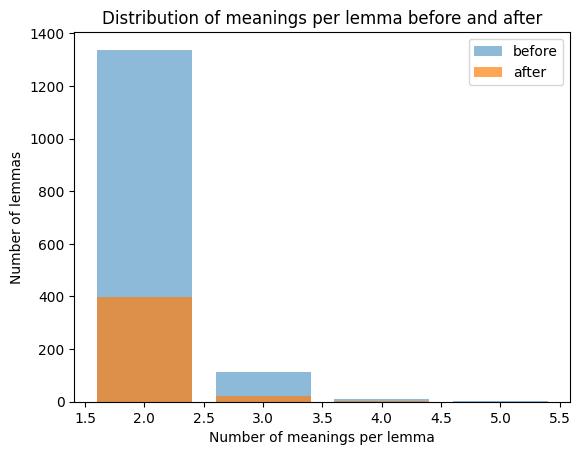

In [27]:
before = Counter([v['before'] for v in before_after.values()])
after = Counter([v['after'] for v in before_after.values() if v['after'] > 0])

# overlap 2 bar plots
plt.bar(before.keys(), before.values(), alpha=0.5, label='before')
plt.bar(after.keys(), after.values(), alpha=0.7, label='after')
plt.legend()
plt.xlabel('Number of meanings per lemma')
plt.ylabel('Number of lemmas')
plt.title('Distribution of meanings per lemma before and after')
plt.show()

In [28]:
print(f"Before we had {sum(before.values())} lemmas, after filtering we have {sum(after.values())} lemmas.")

Before we had 1464 lemmas, after filtering we have 424 lemmas.
